In [1]:
# Cell 1: load and prepare only the controlled variables
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import CSV_PATH
from src.preprocess import load_and_prep_data

controlled_features = [
    "PBEAM_TOT",
    "BZXR",
    "PBEAM_A",
    "PBEAM_B",
    "PBEAM_C",
    "NES"
]

df_clean = load_and_prep_data(
    str(CSV_PATH),
    feature_cols=controlled_features,
)

print("Rows:", len(df_clean))
print("Controlled feature list:", controlled_features)
print("Target column:", "tau_e")

Rows: 1021
Controlled feature list: ['PBEAM_TOT', 'BZXR', 'PBEAM_A', 'PBEAM_B', 'PBEAM_C', 'NES']
Target column: tau_e


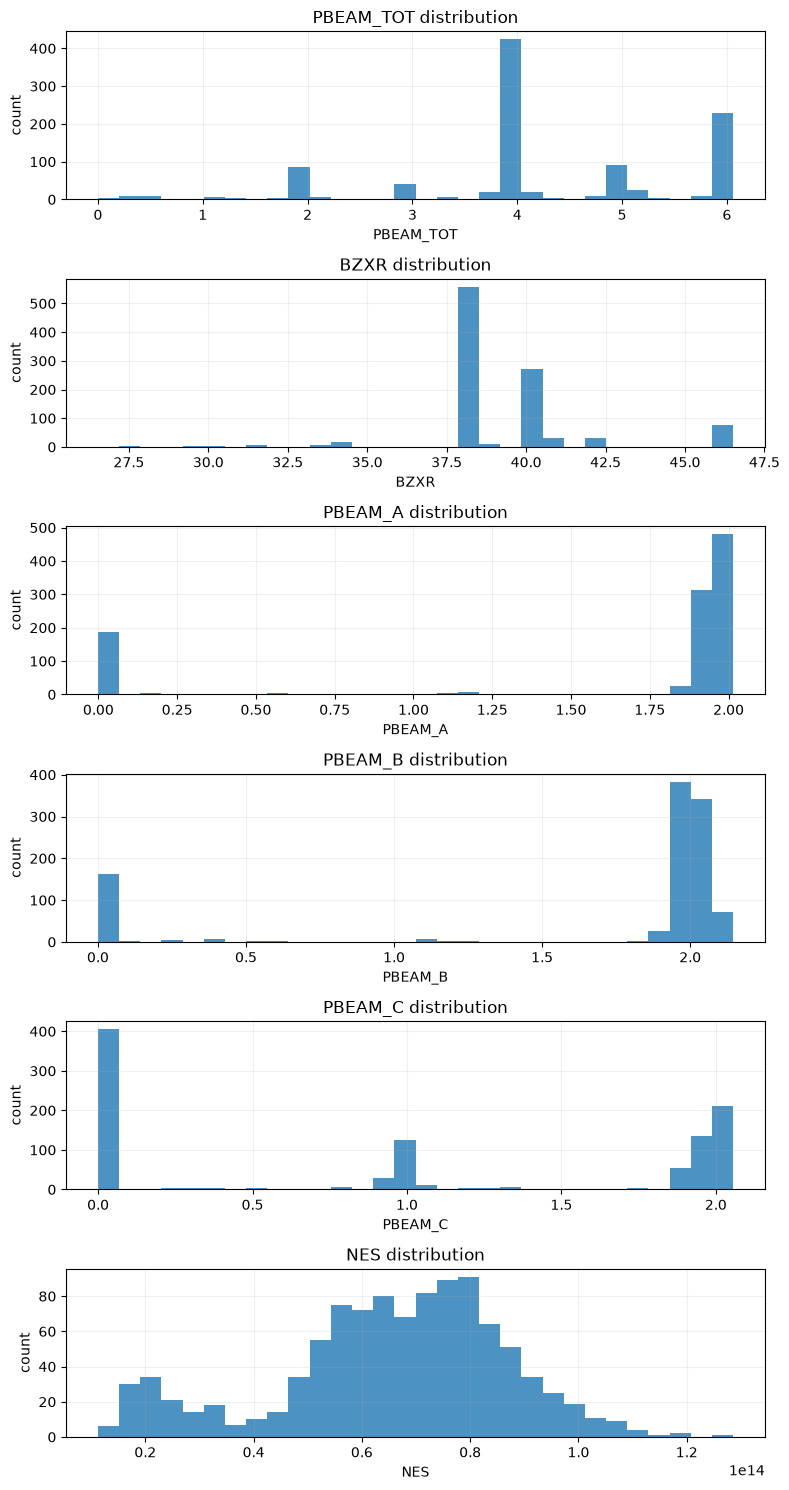

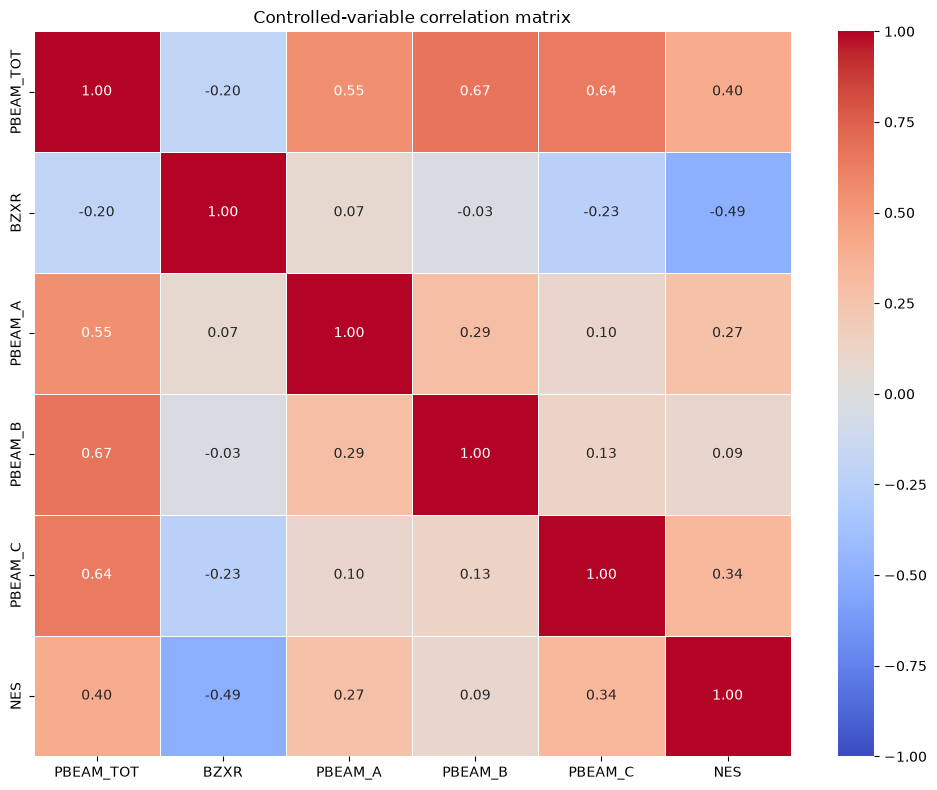

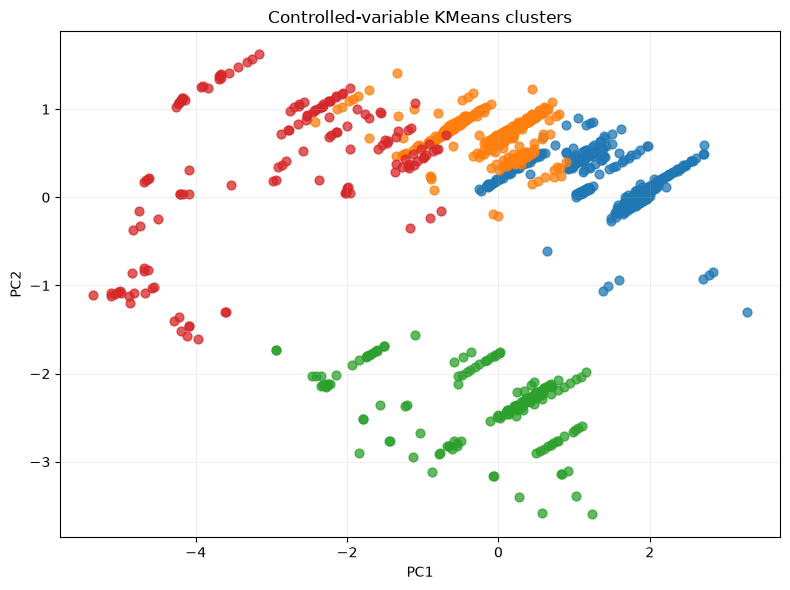

         PBEAM_TOT       BZXR   PBEAM_A   PBEAM_B   PBEAM_C           NES  \
Cluster                                                                     
0         5.585592  38.391067  1.962471  1.791832  1.831288  7.887373e+13   
1         4.150072  39.561745  1.948406  1.991862  0.209805  6.522777e+13   
2         3.477159  37.619842 -0.000368  1.961965  1.515562  5.747248e+13   
3         1.997204  42.595986  1.506184  0.079163  0.411856  4.570407e+13   

             ETAU  
Cluster            
0        0.037277  
1        0.042064  
2        0.046880  
3        0.039645  


In [3]:
# Cell 2: variable distributions, correlation matrix, and controlled-feature KMeans summary
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1) distributions for the chosen controlled variables
fig, axes = plt.subplots(len(controlled_features), 1, figsize=(8, 2.5 * len(controlled_features)))

if len(controlled_features) == 1:
    axes = [axes]

for ax, col in zip(axes, controlled_features):
    df_clean[col].dropna().plot(kind="hist", bins=30, ax=ax, alpha=0.8)
    ax.set_title(f"{col} distribution")
    ax.set_xlabel(col)
    ax.set_ylabel("count")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# 2) correlation matrix for the chosen controlled variables
corr = df_clean[controlled_features].corr(method = "spearman")

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f",
    linewidths=0.5,
    ax=ax
)
ax.set_title("Controlled-variable correlation matrix")
plt.tight_layout()
plt.show()

# 3) canonical KMeans clustering summary for the chosen controlled variables
X = df_clean[controlled_features].copy()
X = X.replace([np.inf, -np.inf], np.nan).dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

km = KMeans(n_clusters=4, random_state=42, n_init=25)
labels = km.fit_predict(X_scaled)

# plot KMeans clusters in PCA space
fig, ax = plt.subplots(figsize=(8, 6))
for cl in np.unique(labels):
    mask = labels == cl
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=40, alpha=0.75)

ax.set_title("Controlled-variable KMeans clusters")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# summary table by cluster
cluster_summary = (
    df_clean.loc[X.index]
    .assign(Cluster=labels)
    .groupby("Cluster")[controlled_features + ["ETAU"]]
    .mean()
)

print(cluster_summary)